### K-Nearest Neighbors

In [24]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

print ("librerias ok")

librerias ok


In [17]:
#Se descargo el dataset en la clase anterior
# El link se saca de lo que me dice kaggle antes
df_test = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/competitions/titanic/Test.csv")
df_train = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/competitions/titanic/Train.csv")
#Unimos los dos dataset
df_concat = pd.concat([df_train, df_test], ignore_index=True)
#Verificamos
print(f"Hay {len(df_test)} registros en test")
print(f"Hay {len(df_train)} registros en train")
print(f"Hay {len(df_concat)} registros en total")

# Objetivo del proyecto: Predecir si sobrevivieron o no
#Hacemos una copia del df para no trabajar sobre la original
df = df_concat.copy()
df.columns

Hay 418 registros en test
Hay 891 registros en train
Hay 1309 registros en total


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [18]:
#Se rellenan edades faltantes con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())

#Se convierte el sexo a numeros
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female': 1})

columnas =['Survived', 'Pclass', 'Sex_encoded','Age', 'SibSp', 'Parch']
df = df[columnas].dropna()

#Determinar variables del modelo
X =df.drop('Survived', axis = 1)
y = df['Survived']

In [20]:
#01. Se dividen los datos en entrenamiento y testeo como venimos haciendo
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.20, random_state = 42)

In [21]:
# 02. Estandarizar para poder medir distancias
scaler = StandardScaler()


In [ ]:
# 03. Aca se estandarizan todas las variables para dejarlas listas
# La diferencia está en que uno aprende los parámetros del escalado y el otro solo los aplica.
X_train_scaled = scaler.fit_transform (X_train)

X_test_scaled = scaler.transform (X_test)

In [ ]:
# 04 Comenzamos a implementar el modelo KNN
# Probar distintos cantidad de vecinos para ver como mejora/empeora el modelo
cantidad_vecinos = 5

#En este caso es un modelo de clasificacion
modelo_knn = KNeighborsClassifier (n_neighbors = cantidad_vecinos)

In [26]:
# 05. Aplico el modelo a mis datos: entrenamiento
modelo_knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [27]:
# 06. Predecir
y_pred = modelo_knn.predict(X_test_scaled)

In [ ]:
# 07. Evaluamos el modelo con la matriz de confusion

acc = accuracy_score (y_test, y_pred)

#Vamos a forzar el orden.  1==> Sobrevive 
# Prestar atencion a este orden!!
cm = confusion_matrix (y_test, y_pred, labels = [1,0])

print(f"Acuracy score: {acc}")
print(f"Matriz de confusion: {cm}")

Acuracy score: 0.7877094972067039
Matriz de confusion: [[54 20]
 [18 87]]


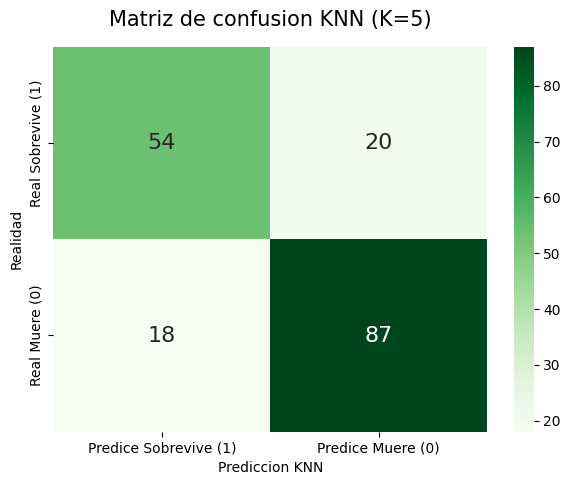


               precision    recall  f1-score   support

         0.0       0.81      0.83      0.82       105
         1.0       0.75      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [32]:
# 08. hacemos un plot para entender mejor las metricas

plt.figure (figsize = (7,5))
#Se invierten las etiquetas, se actualizan los textos para que coincidan con el nievo orden.
sns.heatmap (cm, annot = True, fmt ="d", cmap ="Greens", annot_kws = {"size": 16},
             xticklabels = ["Predice Sobrevive (1)", "Predice Muere (0)"],
            yticklabels = ["Real Sobrevive (1)", "Real Muere (0)"])

plt.title(f"Matriz de confusion KNN (K={cantidad_vecinos})", fontsize = 15, pad =15)
plt.ylabel("Realidad")
plt.xlabel("Prediccion KNN")
plt.show()
print ("\n", classification_report(y_test, y_pred)) 

El valor que mas me preocupa en este caso es el 18. En este caso dije que sobreviven 18 pero son los que se murieron
74 son los que sobrevivieron y 105 murieron

recall 0.73 quiere decir que yo pude identificar el 73%. Que serian 3 cada 4 sobrevivientes


El modelo KNN obtuvo una accuracy del 79%, lo que significa que clasificó correctamente aproximadamente 8 de cada 10 pasajeros del conjunto de prueba. Para la clase "No sobrevivió", alcanzó una precisión del 81% y un recall del 83%, indicando que identifica bastante bien a quienes no sobrevivieron. Para la clase "Sobrevivió", la precisión fue del 75% y el recall del 73%, por lo que, cuando predice que un pasajero sobrevivió, acierta tres de cada cuatro veces, y además logra detectar aproximadamente el 73% de todos los sobrevivientes reales. En conjunto, el modelo presenta un rendimiento equilibrado, aunque clasifica ligeramente mejor a los pasajeros que no sobrevivieron que a los que sí lo hicieron.